# DeepScaleR DAPO / NGU AIME pass@k plots

Pulls the DeepScaleR difficulty-quartile DAPO/NGU runs described in
`experiment.md` from W&B project `ai2-llm/open_instruct_internal` and plots:

- `eval/pass_at_1` (AIME 2025) over training steps, mean +/- SEM across 3 seeds
  per setting.
- Point-wise (early-stopping) pass@k and difficulty-bucketed pass@1, evaluated
  at **each seed's own best step** (the training step with the highest
  `eval/pass_at_1`), then averaged across seeds.
- Prompt difficulty distributions and per-quartile nonzero-prompt ratios
  during training.

**Settings covered:** the 4 baseline N/K configs (`total_episodes=256000`,
128 completions/step) and NGU at `p in {0.5, 0.75, 0.875}` for the N=8, K=16
config, 3 seeds each (28 runs total; NGU p=0.75's original seed-2 attempt
died and was rerun -- see the run registry below).

**Step alignment:** these OLMo-core / active-sampling runs don't log a clean
`eval_step`; `local_eval_every=100` but async/inflight updates mean evals
land near-but-not-exactly on multiples of 100 (e.g. step 107, 207, 306, ...).
We round every raw step to the nearest multiple of 100 (`normalized_step`)
so all runs align on a common x-axis of 100, 200, ..., 2000.

**Difficulty buckets** (hard / medium / easy) reuse the same initial-model
AIME solve-rate table (`w47m67sf`, 64-sample eval on `Qwen3-4B-Base`) as the
DAPO notebook (`../open-instruct-merge/notebooks/dapo.ipynb`), remapped from
that run's quartile-sorted AIME ordering to the plain `problem_idx` ordering
used by `allenai/aime_2025_openinstruct` (the eval set for these runs).

In [1]:
from __future__ import annotations

import json
import math
import pickle
import re
import tempfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from datasets import load_dataset
from IPython.display import Markdown

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"
DATASET_REPO = "mnoukhov/deepscaler-10k-qwen3-4b-base-32samples-quartiles"
AIME_EVAL_KEY = "eval/pass_at_1"  # single eval dataset (AIME 2025), so no dataset-specific prefix needed

STEP_BIN = 100
MAX_STEP = 2000
K_VALUES = [1, 2, 4, 8, 16, 32]

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "figures"
CACHE_DIR = NOTEBOOK_DIR / ".cache" / "deepscaler_ngu"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

api = wandb.Api(timeout=90)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mnoukhov/.netrc.


## Run registry

Wandb run IDs were recovered from each Beaker experiment's description
(`https://wandb.ai/ai2-llm/open_instruct_internal/runs/<id>`), using the
**final/relaunched** Beaker experiment for anything `experiment.md` records
as stalled/crashed and relaunched. Live Beaker job status (last job in each
experiment, to skip over preemption retries) was cross-checked against
`experiment.md` and turned up one additional dead run not caught there:
`2k_ngu075_dapo_n8_k16_seed2` (`4aquxlco`) exited with code 1 at step
832/2000. It was rerun as `kg4ycwi8` (internally named `..._seed4` in
Beaker/W&B, but filling the seed-2 slot for `NGU p=0.75` here); as of this
notebook run that rerun is still in progress (last logged step ~1500/2000),
so its best-step numbers below may still improve.

`2k_baseline_dapo_n4_k32_seed2` was killed and resumed from a checkpoint
under a **new** wandb run (`midlg5cv`, steps ~1900-2000) after the original
run (`txilsd7o`) stalled at step 1896; `stitch_run_id` splices the original
run's earlier steps (<1900) onto the resumed run.

In [3]:
RUN_SPECS = [
    # --- baseline N/K sweep ---
    {"setting": "N=16, K=8", "seed": 1, "run_id": "ys9ymj6v"},
    {"setting": "N=16, K=8", "seed": 2, "run_id": "w24n9eea"},
    {"setting": "N=16, K=8", "seed": 3, "run_id": "xpmxgh19"},
    {"setting": "N=8, K=16", "seed": 1, "run_id": "cmoi4l53"},
    {"setting": "N=8, K=16", "seed": 2, "run_id": "v12nc9i8"},
    {"setting": "N=8, K=16", "seed": 3, "run_id": "02frsm05"},  # relaunched after stall
    {"setting": "N=4, K=32", "seed": 1, "run_id": "t68pmy9s"},
    {"setting": "N=4, K=32", "seed": 2, "run_id": "midlg5cv", "stitch_run_id": "txilsd7o"},  # resumed from checkpoint
    {"setting": "N=4, K=32", "seed": 3, "run_id": "z4448u5r"},
    {"setting": "N=2, K=64", "seed": 1, "run_id": "pxlpna71"},
    {"setting": "N=2, K=64", "seed": 2, "run_id": "blfze1rc"},
    {"setting": "N=2, K=64", "seed": 3, "run_id": "hl3d7uml"},
    # --- NGU p sweep (N=8, K=16 only) ---
    {"setting": "NGU p=0.5", "seed": 1, "run_id": "6rxe8lh5"},
    {"setting": "NGU p=0.5", "seed": 2, "run_id": "rg4c490m"},  # relaunched after stall
    {"setting": "NGU p=0.5", "seed": 3, "run_id": "pdm9oqd6"},
    {"setting": "NGU p=0.75", "seed": 1, "run_id": "i12fv1iu"},
    {"setting": "NGU p=0.75", "seed": 2, "run_id": "kg4ycwi8"},  # rerun of the seed that failed at step 832; Beaker/W&B internally calls this "seed4" but it fills the seed-2 slot
    {"setting": "NGU p=0.75", "seed": 3, "run_id": "ai4avb1d"},  # relaunched after stall
    {"setting": "NGU p=0.875", "seed": 1, "run_id": "x5rkqi9n"},
    {"setting": "NGU p=0.875", "seed": 2, "run_id": "ux8zlyun"},  # relaunched after crash
    {"setting": "NGU p=0.875", "seed": 3, "run_id": "0f6tb0za"},
]

BASELINE_SETTING_ORDER = ["N=16, K=8", "N=8, K=16", "N=4, K=32", "N=2, K=64"]
NGU_SETTING_ORDER = ["N=8, K=16", "NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]
ALL_SETTING_ORDER = ["N=16, K=8", "N=8, K=16", "N=4, K=32", "N=2, K=64", "NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]

INITIAL_RUN_ID = "k3kgf1up"  # zero-shot Qwen3-4B-Base eval (reused from the DAPO notebook; same base model + AIME 2025 set)
INITIAL_RUN_NAME = "initial_eval"
DIFFICULTY_RUN_ID = "w47m67sf"  # 64-sample AIME+BRUMO solve-rate eval on Qwen3-4B-Base (reused from the DAPO notebook)
DIFFICULTY_DATASET_REPO = "mnoukhov/aime-2025-openinstruct-qwen3-4b-base-32samples-quartiles"
DIFFICULTY_NUM_SAMPLES = 64
DIFFICULTY_ORDER = ["hard", "medium", "easy"]

for spec in RUN_SPECS:
    spec.setdefault("excluded", False)
    spec["run_key"] = f"{spec['setting']}__seed{spec['seed']}"

print(f"{len(RUN_SPECS)} training runs registered "
      f"({sum(not s['excluded'] for s in RUN_SPECS)} included, {sum(s['excluded'] for s in RUN_SPECS)} excluded)")

21 training runs registered (21 included, 0 excluded)


## Download everything once (cached to disk under `notebooks/.cache/deepscaler_ngu/`)

In [4]:
EVAL_KEYS = [
    "_step", "eval/pass_at_1", "eval/pass_at_1_unbiased", "eval/pass_at_2_unbiased",
    "eval/pass_at_4_unbiased", "eval/pass_at_8_unbiased", "eval/pass_at_16_unbiased",
    "eval/pass_at_32_unbiased", "eval/prompt_solve_rate_by_index_table",
]
BATCH_KEYS = ["_step", "batch/total_prompts"] + [f"batch/nonzero_prompts/math_deepscaler_quartile{q}" for q in range(4)]
PASS_AT_K_HISTORY_COLS = {
    1: "eval/pass_at_1_unbiased", 2: "eval/pass_at_2_unbiased", 4: "eval/pass_at_4_unbiased",
    8: "eval/pass_at_8_unbiased", 16: "eval/pass_at_16_unbiased", 32: "eval/pass_at_32_unbiased",
}


def normalized_step(step: int | float, *, bin_size: int = STEP_BIN) -> int:
    return int(round(float(step) / bin_size) * bin_size)


def _cache_path(run_id: str) -> Path:
    return CACHE_DIR / f"{run_id}_history.pkl"


def download_run_history(run_id: str) -> dict:
    # Scan eval + batch history for a run once, cached to disk.
    cache_path = _cache_path(run_id)
    if cache_path.exists():
        with open(cache_path, "rb") as fh:
            return pickle.load(fh)
    run = api.run(f"{PROJECT_PATH}/{run_id}")
    eval_rows = [row for row in run.scan_history(keys=EVAL_KEYS, page_size=1000) if row.get(AIME_EVAL_KEY) is not None]
    batch_rows = [row for row in run.scan_history(keys=BATCH_KEYS, page_size=1000) if row.get("batch/total_prompts")]
    data = {"run_id": run_id, "run_name": run.name, "state": run.state, "eval_rows": eval_rows, "batch_rows": batch_rows}
    with open(cache_path, "wb") as fh:
        pickle.dump(data, fh)
    return data


def _table_path_from_entry(entry) -> str:
    if isinstance(entry, dict) and "path" in entry:
        return entry["path"]
    return getattr(entry, "path", None) or entry["_path"]


def _read_table_file(run: wandb.apis.public.Run, table_path: str) -> pd.DataFrame:
    with tempfile.TemporaryDirectory() as tmp_dir:
        downloaded = run.file(table_path).download(root=tmp_dir, replace=True)
        with open(downloaded.name, "r") as fh:
            payload = json.load(fh)
    table_df = pd.DataFrame(payload["data"], columns=payload["columns"])
    table_df["dataset_index"] = pd.to_numeric(table_df["dataset_index"], errors="raise").astype(int)
    table_df["solve_rate"] = pd.to_numeric(table_df["solve_rate"], errors="raise").astype(float)
    return table_df.sort_values("dataset_index").reset_index(drop=True)


def download_solve_rate_table(run_id: str, *, table_entry, cache_key: str) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"{cache_key}_solve_rate_table.pkl"
    if cache_path.exists():
        return pd.read_pickle(cache_path)
    run = api.run(f"{PROJECT_PATH}/{run_id}")
    table_df = _read_table_file(run, _table_path_from_entry(table_entry))
    table_df.to_pickle(cache_path)
    return table_df

In [5]:
def eval_rows_to_df(eval_rows: list[dict], *, source_run_id: str) -> pd.DataFrame:
    df = pd.DataFrame(eval_rows)
    df = df.drop_duplicates(subset="_step", keep="last").sort_values("_step").reset_index(drop=True)
    df["normalized_step"] = df["_step"].map(normalized_step).clip(upper=MAX_STEP)
    df["_source_run_id"] = source_run_id  # which wandb run actually logged this row (differs for stitched runs)
    return df


def batch_rows_to_df(batch_rows: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(batch_rows).sort_values("_step").reset_index(drop=True)
    total = df["batch/total_prompts"].replace(0, np.nan)
    for q in range(4):
        df[f"q{q}_ratio"] = df[f"batch/nonzero_prompts/math_deepscaler_quartile{q}"] / total * 100
    return df


run_data: dict[str, dict] = {}
for spec in RUN_SPECS:
    raw = download_run_history(spec["run_id"])
    eval_df = eval_rows_to_df(raw["eval_rows"], source_run_id=spec["run_id"])
    batch_df = batch_rows_to_df(raw["batch_rows"])

    if "stitch_run_id" in spec:
        stitch_raw = download_run_history(spec["stitch_run_id"])
        stitch_eval_df = eval_rows_to_df(stitch_raw["eval_rows"], source_run_id=spec["stitch_run_id"])
        stitch_batch_df = batch_rows_to_df(stitch_raw["batch_rows"])
        cutoff = eval_df["_step"].min()
        eval_df = pd.concat([stitch_eval_df[stitch_eval_df["_step"] < cutoff], eval_df], ignore_index=True)
        batch_cutoff = batch_df["_step"].min()
        batch_df = pd.concat([stitch_batch_df[stitch_batch_df["_step"] < batch_cutoff], batch_df], ignore_index=True)
        eval_df = eval_df.drop_duplicates(subset="normalized_step", keep="last").sort_values("_step").reset_index(drop=True)

    run_data[spec["run_key"]] = {"spec": spec, "eval_df": eval_df, "batch_df": batch_df, "run_name": raw["run_name"]}

print(f"Downloaded/loaded history for {len(run_data)} runs")

Downloaded/loaded history for 21 runs


In [6]:
# Best (early-stopping) step per run = the raw step with the highest AIME pass@1.
best_step_rows = []
for run_key, d in run_data.items():
    eval_df = d["eval_df"]
    best_idx = eval_df[AIME_EVAL_KEY].idxmax()
    best_row = eval_df.loc[best_idx]
    d["best_row"] = best_row
    spec = d["spec"]
    best_step_rows.append({
        "setting": spec["setting"],
        "seed": spec["seed"],
        "run_id": spec["run_id"],
        "best_step_source_run_id": best_row["_source_run_id"],
        "excluded": spec["excluded"],
        "best_raw_step": int(best_row["_step"]),
        "best_normalized_step": int(best_row["normalized_step"]),
        "best_pass_at_1": float(best_row[AIME_EVAL_KEY]),
        "final_pass_at_1": float(eval_df.iloc[-1][AIME_EVAL_KEY]),
    })

best_step_df = pd.DataFrame(best_step_rows)
best_step_df["setting"] = pd.Categorical(best_step_df["setting"], categories=ALL_SETTING_ORDER, ordered=True)
best_step_df = best_step_df.sort_values(["setting", "seed"]).reset_index(drop=True)
display(best_step_df)

,setting,seed,run_id,best_step_source_run_id,excluded,best_raw_step,best_normalized_step,best_pass_at_1,final_pass_at_1
0,"N=16, K=8",1,ys9ymj6v,ys9ymj6v,False,1103,1100,0.168750,0.138542
1,"N=16, K=8",2,w24n9eea,w24n9eea,False,1103,1100,0.229167,0.185417
2,"N=16, K=8",3,xpmxgh19,xpmxgh19,False,1902,1900,0.216667,0.202083
3,"N=8, K=16",1,cmoi4l53,cmoi4l53,False,903,900,0.227083,0.214583
4,"N=8, K=16",2,v12nc9i8,v12nc9i8,False,1403,1400,0.239583,0.223958
5,"N=8, K=16",3,02frsm05,02frsm05,False,1503,1500,0.198958,0.179167
6,"N=4, K=32",1,t68pmy9s,t68pmy9s,False,1204,1200,0.207292,0.162500
7,"N=4, K=32",2,midlg5cv,txilsd7o,False,805,800,0.207292,0.177083
8,"N=4, K=32",3,z4448u5r,z4448u5r,False,1205,1200,0.231250,0.204167
9,"N=2, K=64",1,pxlpna71,pxlpna71,False,1005,1000,0.214583,0.196875


In [7]:
# Solve-rate-by-index table at each run's own best step (for difficulty-bucket / per-dataset plots).
for run_key, d in run_data.items():
    best_row = d["best_row"]
    entry = best_row["eval/prompt_solve_rate_by_index_table"]
    table_df = download_solve_rate_table(best_row["_source_run_id"], table_entry=entry, cache_key=run_key)
    d["best_step_solve_rate_df"] = table_df

print("Downloaded best-step solve-rate tables for all runs")

Downloaded best-step solve-rate tables for all runs


## Difficulty buckets (reused from the DAPO notebook's initial-model AIME eval)

`w47m67sf` evaluated `Qwen3-4B-Base` (the same base checkpoint used here) on
a combined AIME+BRUMO set with 64 samples/prompt; its solve-rate table indexes
prompts in the order of `mnoukhov/aime-2025-openinstruct-qwen3-4b-base-32samples-quartiles`,
which is quartile-sorted (not by `problem_idx`). Our runs evaluate on
`allenai/aime_2025_openinstruct`, whose `dataset_index` is exactly
`problem_idx - 1` (verified below). We remap `w47m67sf`'s AIME rows
(`dataset_index < 30`) through `problem_idx` onto our runs' `dataset_index`
space so the difficulty buckets line up with our tables.

In [8]:
difficulty_run = api.run(f"{PROJECT_PATH}/{DIFFICULTY_RUN_ID}")
w47_table_df = _read_table_file(difficulty_run, _table_path_from_entry(difficulty_run.summary["eval/prompt_solve_rate_by_index_table"]))
w47_aime_df = w47_table_df[w47_table_df["dataset_index"] < 30].reset_index(drop=True)

diff_source_df = load_dataset(DIFFICULTY_DATASET_REPO, split="train").to_pandas().reset_index().rename(columns={"index": "dataset_index"})
allenai_aime_df = load_dataset("allenai/aime_2025_openinstruct", split="train").to_pandas().reset_index().rename(columns={"index": "dataset_index"})
assert (allenai_aime_df["dataset_index"] == allenai_aime_df["problem_idx"] - 1).all(), "allenai AIME ordering assumption broke"

w47_aime_df = w47_aime_df.merge(diff_source_df[["dataset_index", "problem_idx"]], on="dataset_index")
initial_solve_df = w47_aime_df.assign(dataset_index=lambda df: df["problem_idx"] - 1)[["dataset_index", "solve_rate"]]
initial_solve_df["pass_count"] = (initial_solve_df["solve_rate"] * DIFFICULTY_NUM_SAMPLES).round().astype(int)
initial_solve_df = initial_solve_df.sort_values("dataset_index").reset_index(drop=True)
print(f"Remapped {len(initial_solve_df)} AIME prompts to allenai/aime_2025_openinstruct dataset_index ordering")
display(initial_solve_df.head())

Remapped 30 AIME prompts to allenai/aime_2025_openinstruct dataset_index ordering


,dataset_index,solve_rate,pass_count
0,0,0.515625,33
1,1,0.000000,0
2,2,0.218750,14
3,3,0.046875,3
4,4,0.078125,5


In [9]:
def assign_difficulty_buckets(initial_df: pd.DataFrame) -> pd.DataFrame:
    # hard: solve_rate == 0; remainder split evenly into easy (top half) / medium.
    df = initial_df.copy()
    hard_mask = df["solve_rate"] <= 0
    df.loc[hard_mask, "difficulty"] = "hard"

    remainder = df.loc[~hard_mask].sort_values("solve_rate", ascending=False).reset_index(drop=True)
    n_easy = len(remainder) // 2 + (len(remainder) % 2)
    easy_indices = remainder.loc[: n_easy - 1, "dataset_index"].tolist()
    medium_indices = remainder.loc[n_easy:, "dataset_index"].tolist()
    df.loc[df["dataset_index"].isin(easy_indices), "difficulty"] = "easy"
    df.loc[df["dataset_index"].isin(medium_indices), "difficulty"] = "medium"
    df["difficulty"] = pd.Categorical(df["difficulty"], categories=DIFFICULTY_ORDER, ordered=True)
    return df


difficulty_assignments_df = assign_difficulty_buckets(initial_solve_df)
diff_lookup = difficulty_assignments_df.set_index("dataset_index")["difficulty"]
difficulty_counts = difficulty_assignments_df["difficulty"].value_counts().reindex(DIFFICULTY_ORDER).astype(int)
difficulty_tick_labels = [f"{d}\n(n={difficulty_counts[d]})" for d in DIFFICULTY_ORDER]
# initial_eval has no seeds to average over, so its per-bucket rate is computed once here
# and reused directly by the improvement-over-initial plots below (not folded into per_seed_df).
initial_bucket_pass_at_1 = difficulty_assignments_df.groupby("difficulty", observed=True)["solve_rate"].mean()
print(difficulty_counts)

difficulty
hard      17
medium     6
easy       7
Name: count, dtype: int64


In [10]:
initial_run = api.run(f"{PROJECT_PATH}/{INITIAL_RUN_ID}")
INITIAL_PASS_AT_1 = float(initial_run.summary["eval/math_aime_2025/pass_at_1"])
INITIAL_PASS_AT_K = {k: float(initial_run.summary[f"eval/math_aime_2025/pass_at_{k}"]) for k in K_VALUES}
print(f"initial_eval pass@1 = {INITIAL_PASS_AT_1:.4f}")
print(INITIAL_PASS_AT_K)

initial_eval pass@1 = 0.0516
{1: 0.05161830357142857, 2: 0.0909148185483871, 4: 0.14438128178134435, 8: 0.19941538624519717, 16: 0.24778850494107788, 32: 0.29464285714285715}


## Plot theme

In [11]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

baseline_palette = dict(zip(BASELINE_SETTING_ORDER, sns.color_palette("Blues", n_colors=len(BASELINE_SETTING_ORDER) + 2)[2:]))
baseline_ratio_palette = dict(zip(BASELINE_SETTING_ORDER, sns.color_palette("Greys", n_colors=len(BASELINE_SETTING_ORDER) + 3)[2:-1]))
ngu_palette = {
    "N=8, K=16": "#555555",
    "NGU p=0.5": "#9ecae1",
    "NGU p=0.75": "#4292c6",
    "NGU p=0.875": "#08306b",
}

# For the combined NGU ratio plot: baselines K=16/32/64 in greyscale, NGU p-sweep in bluescale.
NGU_RATIO_BASELINE_SETTINGS = ["N=8, K=16", "N=4, K=32", "N=2, K=64"]
NGU_RATIO_SETTING_ORDER = NGU_RATIO_BASELINE_SETTINGS + ["NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]
ngu_ratio_palette = dict(zip(
    NGU_RATIO_BASELINE_SETTINGS,
    sns.color_palette("Greys", n_colors=len(NGU_RATIO_BASELINE_SETTINGS) + 3)[2:-1],
))
ngu_ratio_palette.update({
    "NGU p=0.5": "#9ecae1",
    "NGU p=0.75": "#4292c6",
    "NGU p=0.875": "#08306b",
})

## `eval/pass_at_1` over training, mean +/- SEM across seeds

Full trajectories (not point-wise) -- normalized to the common 100..2000 step
grid, averaged per setting across the (non-excluded) seeds.

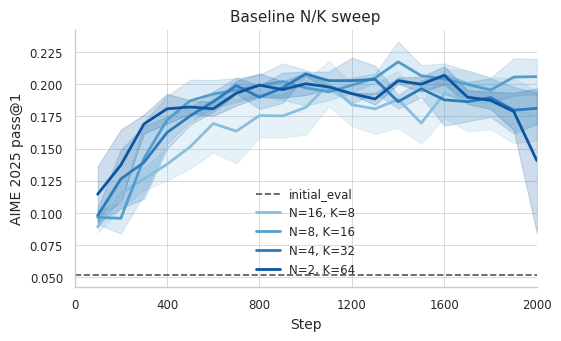

In [12]:
def build_pass_at_1_long_df(setting_order: list[str]) -> pd.DataFrame:
    rows = []
    for d in run_data.values():
        spec = d["spec"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        eval_df = d["eval_df"]
        per_step = eval_df.groupby("normalized_step")[AIME_EVAL_KEY].last()
        for step, value in per_step.items():
            rows.append({"setting": spec["setting"], "seed": spec["seed"], "Step": int(step), "value": float(value)})
    df = pd.DataFrame(rows)
    df["setting"] = pd.Categorical(df["setting"], categories=setting_order, ordered=True)
    return df.sort_values(["setting", "seed", "Step"]).reset_index(drop=True)


def plot_pass_at_1_over_steps(df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None):
    fig, ax = plt.subplots(figsize=(5.5, 3.3), constrained_layout=True)
    ax.axhline(INITIAL_PASS_AT_1, color="#555555", linestyle="--", linewidth=1.2, label=INITIAL_RUN_NAME, zorder=1)
    sns.lineplot(
        data=df, x="Step", y="value", hue="setting", hue_order=setting_order, palette=palette,
        errorbar="se", estimator="mean", ax=ax,
    )
    ax.set_xlabel("Step")
    ax.set_ylabel("AIME 2025 pass@1")
    ax.set_xlim(0, MAX_STEP)
    ax.set_xticks(range(0, MAX_STEP + STEP_BIN, 400))
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="best")
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


baseline_pass_at_1_df = build_pass_at_1_long_df(BASELINE_SETTING_ORDER)
plot_pass_at_1_over_steps(baseline_pass_at_1_df, BASELINE_SETTING_ORDER, baseline_palette,
                           "deepscaler_baseline_aime_2025_pass_at_1.pdf", "Baseline N/K sweep")
plt.show()

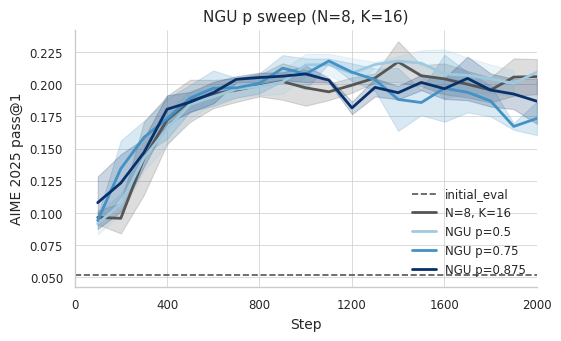

In [13]:
ngu_pass_at_1_df = build_pass_at_1_long_df(NGU_SETTING_ORDER)
plot_pass_at_1_over_steps(ngu_pass_at_1_df, NGU_SETTING_ORDER, ngu_palette,
                           "deepscaler_ngu_aime_2025_pass_at_1.pdf", "NGU p sweep (N=8, K=16)")
plt.show()

## Point-wise pass@k, at each seed's own best (early-stopping) step

For each seed, use the training step where `eval/pass_at_1` peaked (from the
`best_step_df` table above), read off pass@k at that same step, then average
across seeds per setting.

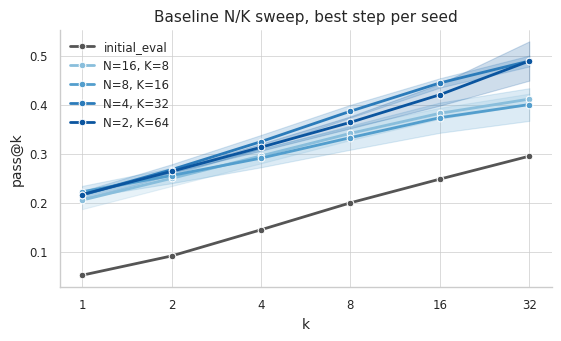

In [14]:
def build_pass_at_k_df(setting_order: list[str]) -> pd.DataFrame:
    rows = [{"setting": INITIAL_RUN_NAME, "k": k, "value": v} for k, v in INITIAL_PASS_AT_K.items()]
    for d in run_data.values():
        spec, best_row = d["spec"], d["best_row"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        for k, col in PASS_AT_K_HISTORY_COLS.items():
            rows.append({"setting": spec["setting"], "seed": spec["seed"], "k": k, "value": float(best_row[col])})
    df = pd.DataFrame(rows)
    label_order = [INITIAL_RUN_NAME, *setting_order]
    df["setting"] = pd.Categorical(df["setting"], categories=label_order, ordered=True)
    return df.sort_values(["setting", "k"]).reset_index(drop=True)


def plot_pass_at_k(df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None):
    label_order = [INITIAL_RUN_NAME, *setting_order]
    full_palette = {INITIAL_RUN_NAME: "#555555", **palette}
    fig, ax = plt.subplots(figsize=(5.5, 3.3), constrained_layout=True)
    sns.lineplot(
        data=df, x="k", y="value", hue="setting", hue_order=label_order, palette=full_palette,
        errorbar="se", estimator="mean", marker="o", ax=ax,
    )
    ax.set_xlabel("k")
    ax.set_ylabel("pass@k")
    ax.set_xscale("log", base=2)
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([str(k) for k in K_VALUES])
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="best")
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


baseline_pass_at_k_df = build_pass_at_k_df(BASELINE_SETTING_ORDER)
plot_pass_at_k(baseline_pass_at_k_df, BASELINE_SETTING_ORDER, baseline_palette,
               "deepscaler_baseline_aime_2025_best_step_pass_at_k.pdf", "Baseline N/K sweep, best step per seed")
plt.show()

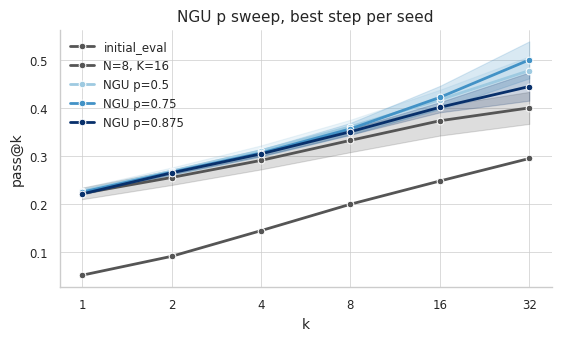

In [15]:
ngu_pass_at_k_df = build_pass_at_k_df(NGU_SETTING_ORDER)
plot_pass_at_k(ngu_pass_at_k_df, NGU_SETTING_ORDER, ngu_palette,
               "deepscaler_ngu_aime_2025_best_step_pass_at_k.pdf", "NGU p sweep, best step per seed")
plt.show()

## Point-wise `pass_at_1_by_difficulty`, at each seed's own best step

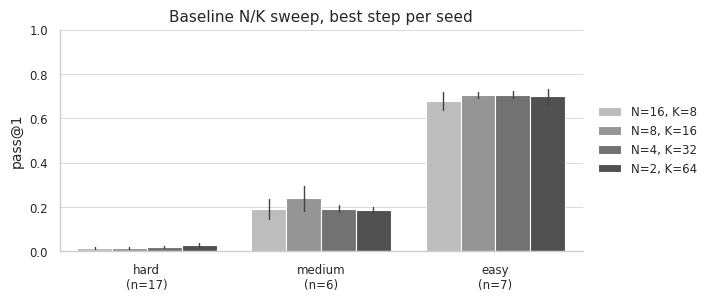

In [16]:
def build_bucket_accuracy_df(setting_order: list[str]) -> pd.DataFrame:
    rows = []
    for d in run_data.values():
        spec = d["spec"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        table_df = d["best_step_solve_rate_df"].copy()
        table_df["setting"] = spec["setting"]
        table_df["seed"] = spec["seed"]
        table_df["difficulty"] = table_df["dataset_index"].map(diff_lookup).astype(
            pd.CategoricalDtype(categories=DIFFICULTY_ORDER, ordered=True)
        )
        rows.append(table_df[["dataset_index", "solve_rate", "difficulty", "setting", "seed"]])

    solve_df = pd.concat(rows, ignore_index=True)
    # per-seed mean over prompts in a bucket, then mean +/- sem across seeds
    per_seed = solve_df.groupby(["setting", "seed", "difficulty"], observed=True)["solve_rate"].mean().reset_index()
    per_seed["setting"] = pd.Categorical(per_seed["setting"], categories=setting_order, ordered=True)
    return per_seed.rename(columns={"solve_rate": "pass_at_1"})


def plot_bucket_accuracy(per_seed_df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None):
    fig, ax = plt.subplots(figsize=(7.0, 2.9), constrained_layout=True)
    sns.barplot(
        data=per_seed_df, x="difficulty", y="pass_at_1", hue="setting", hue_order=setting_order,
        palette=palette, order=DIFFICULTY_ORDER, errorbar="se", err_kws={"linewidth": 1.0}, ax=ax,
    )
    ax.set_xlabel("")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels)
    ax.set_ylabel("pass@1")
    ax.set_ylim(0, 1)
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


baseline_bucket_df = build_bucket_accuracy_df(BASELINE_SETTING_ORDER)
plot_bucket_accuracy(baseline_bucket_df, BASELINE_SETTING_ORDER, baseline_ratio_palette,
                      "deepscaler_baseline_pass_at_1_by_difficulty.pdf", "Baseline N/K sweep, best step per seed")
plt.show()

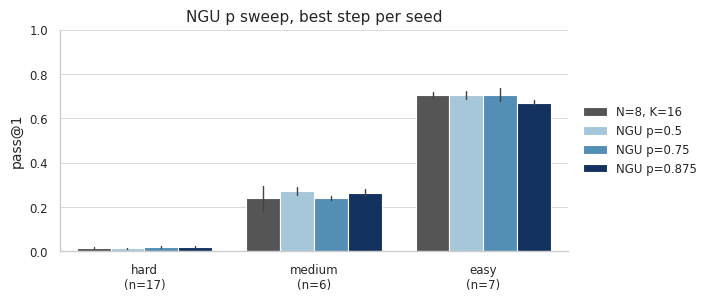

In [17]:
ngu_bucket_df = build_bucket_accuracy_df(NGU_SETTING_ORDER)
plot_bucket_accuracy(ngu_bucket_df, NGU_SETTING_ORDER, ngu_palette,
                      "deepscaler_ngu_pass_at_1_by_difficulty.pdf", "NGU p sweep, best step per seed")
plt.show()

### Improvement over `initial_eval`, by difficulty bucket

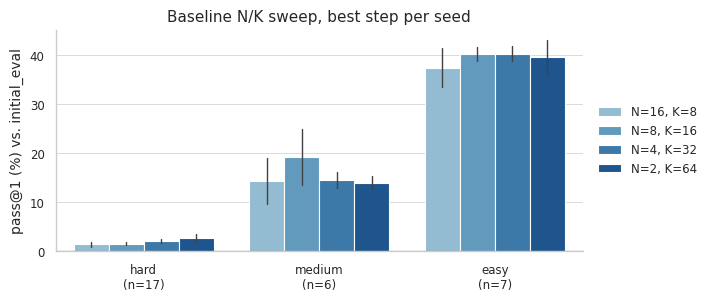

difficulty,hard,medium,easy
setting,,,
"N=16, K=8",1.470588,14.409722,37.500000
"N=8, K=16",1.593137,19.270833,40.327381
"N=4, K=32",2.083333,14.583333,40.327381
"N=2, K=64",2.757353,14.062500,39.583333


In [18]:
def plot_bucket_improvement(per_seed_df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None):
    improvement_df = per_seed_df.copy()
    improvement_df["improvement"] = (
        improvement_df["pass_at_1"].astype(float) - improvement_df["difficulty"].map(initial_bucket_pass_at_1).astype(float)
    ) * 100
    improvement_df["setting"] = pd.Categorical(improvement_df["setting"], categories=setting_order, ordered=True)

    fig, ax = plt.subplots(figsize=(7.0, 2.9), constrained_layout=True)
    sns.barplot(
        data=improvement_df, x="difficulty", y="improvement", hue="setting", hue_order=setting_order,
        palette=palette, order=DIFFICULTY_ORDER, errorbar="se", err_kws={"linewidth": 1.0}, ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels)
    ax.set_ylabel("pass@1 (%) vs. initial_eval")
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax, improvement_df


_, _, baseline_improvement_df = plot_bucket_improvement(
    baseline_bucket_df, BASELINE_SETTING_ORDER, baseline_palette,
    "deepscaler_baseline_pass_at_1_improvement_by_difficulty.pdf", "Baseline N/K sweep, best step per seed",
)
plt.show()
display(baseline_improvement_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())

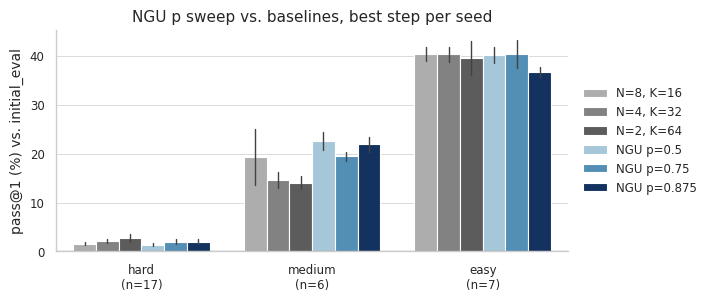

difficulty,hard,medium,easy
setting,,,
"N=8, K=16",1.593137,19.270833,40.327381
"N=4, K=32",2.083333,14.583333,40.327381
"N=2, K=64",2.757353,14.062500,39.583333
NGU p=0.5,1.409314,22.569444,40.178571
NGU p=0.75,2.022059,19.444444,40.327381
NGU p=0.875,1.960784,21.875000,36.755952


In [19]:
ngu_full_bucket_df = build_bucket_accuracy_df(NGU_RATIO_SETTING_ORDER)
_, _, ngu_improvement_df = plot_bucket_improvement(
    ngu_full_bucket_df, NGU_RATIO_SETTING_ORDER, ngu_ratio_palette,
    "deepscaler_ngu_pass_at_1_improvement_by_difficulty.pdf", "NGU p sweep vs. baselines, best step per seed",
)
plt.show()
display(ngu_improvement_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())

## Fraction of nonzero-reward prompts per training batch, by *training-data* quartile

Compares the easiest (`math_deepscaler_quartile0`) and hardest
(`math_deepscaler_quartile3`) training-data quartiles across settings, EMA
smoothed like the DAPO notebook.

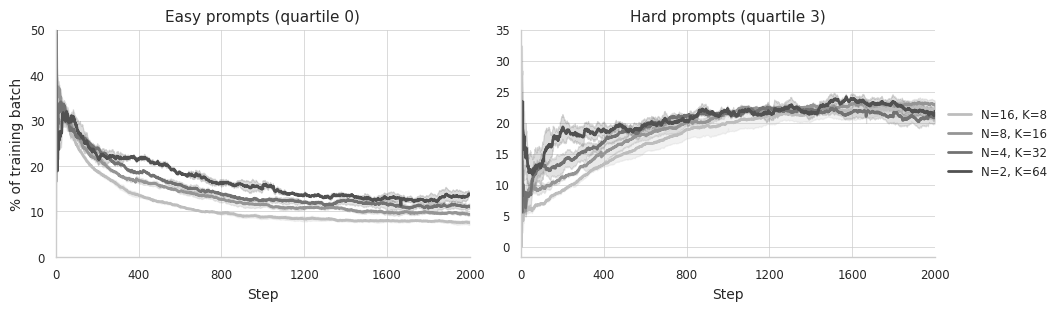

In [20]:
RATIO_EMA_DECAY = 0.995


def build_ratio_df(setting_order: list[str]) -> pd.DataFrame:
    rows = []
    for d in run_data.values():
        spec = d["spec"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        batch_df = d["batch_df"]
        sub = batch_df[(batch_df["_step"] >= 0) & (batch_df["_step"] <= MAX_STEP)]
        rows.append(pd.DataFrame({
            "setting": spec["setting"], "seed": spec["seed"], "run_id": spec["run_id"],
            "Step": sub["_step"].values, "q0_ratio": sub["q0_ratio"].values, "q3_ratio": sub["q3_ratio"].values,
        }))
    df = pd.concat(rows, ignore_index=True)
    for col in ("q0_ratio", "q3_ratio"):
        df[col] = (
            df.sort_values(["setting", "run_id", "Step"])
            .groupby(["setting", "run_id"], observed=True)[col]
            .transform(lambda s: s.ewm(alpha=1 - RATIO_EMA_DECAY, adjust=True).mean())
        )
    df["setting"] = pd.Categorical(df["setting"], categories=setting_order, ordered=True)
    return df


def plot_ratio(df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str):
    fig, (ax_q0, ax_q3) = plt.subplots(1, 2, figsize=(10.5, 3.0), constrained_layout=True)
    for ax, ycol, title in [(ax_q0, "q0_ratio", "Easy prompts (quartile 0)"), (ax_q3, "q3_ratio", "Hard prompts (quartile 3)")]:
        sns.lineplot(data=df, x="Step", y=ycol, hue="setting", hue_order=setting_order, palette=palette, errorbar="se", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Step")
        ax.set_ylabel("% of training batch" if ax is ax_q0 else "")
        ax.set_xlim(0, MAX_STEP)
        ax.set_xticks(range(0, MAX_STEP + 1, 400))
        if ax is ax_q0:
            ax.set_ylim(0, 50)
        sns.despine(ax=ax)
    ax_q3.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    if ax_q0.get_legend() is not None:
        ax_q0.get_legend().remove()
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, (ax_q0, ax_q3)


baseline_ratio_df = build_ratio_df(BASELINE_SETTING_ORDER)
plot_ratio(baseline_ratio_df, BASELINE_SETTING_ORDER, baseline_ratio_palette, "deepscaler_baseline_nonzero_prompt_ratio.pdf")
plt.show()

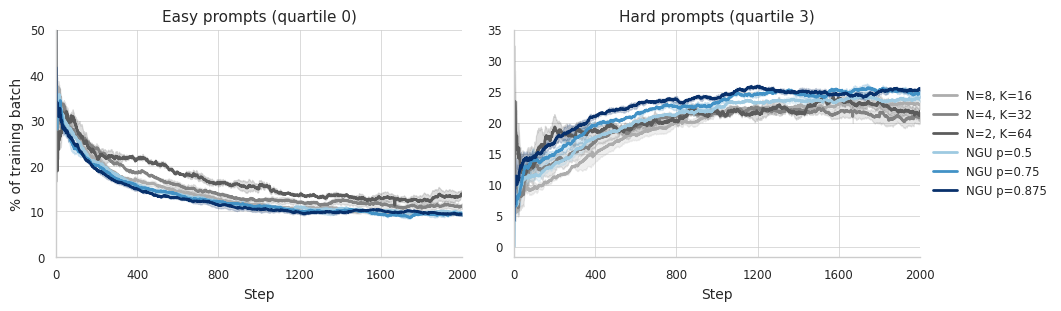

In [21]:
ngu_ratio_df = build_ratio_df(NGU_RATIO_SETTING_ORDER)
plot_ratio(ngu_ratio_df, NGU_RATIO_SETTING_ORDER, ngu_ratio_palette, "deepscaler_ngu_nonzero_prompt_ratio.pdf")
plt.show()

## Training-data prompt difficulty distribution

pass@32 histogram of the DeepScaleR 10k training prompts, colored by
difficulty quartile (mirrors `deepscaler_pass_rate_quartiles.ipynb`).

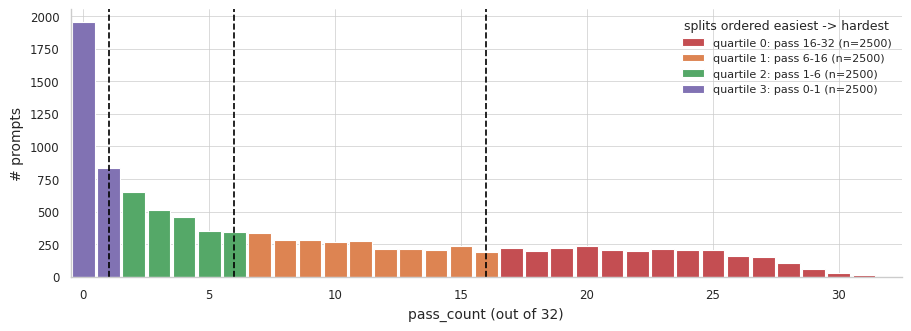

In [22]:
def extract_pass_count(row: pd.Series) -> int:
    pass_count = row.get("pass_count")
    if pd.notna(pass_count):
        return int(pass_count)
    pass_rate = row.get("pass_rate")
    if isinstance(pass_rate, str) and "/" in pass_rate:
        return int(pass_rate.split("/", 1)[0].strip())
    raise ValueError("Row is missing pass_count and parseable pass_rate")


train_difficulty_df = load_dataset(DATASET_REPO, split="train").to_pandas()
train_difficulty_df["pass_count"] = train_difficulty_df.apply(extract_pass_count, axis=1)
train_num_samples = int(train_difficulty_df["num_samples"].iloc[0]) if "num_samples" in train_difficulty_df.columns else 32
train_difficulty_df["quartile"] = train_difficulty_df["dataset"].str.extract(r"quartile(\d+)").astype(int)

pass_values = np.arange(train_num_samples + 1)
counts = train_difficulty_df["pass_count"].value_counts().reindex(pass_values, fill_value=0).sort_index()
maj_quartile = train_difficulty_df.groupby("pass_count")["quartile"].agg(lambda s: s.mode().iloc[0]).reindex(pass_values)
qstats = train_difficulty_df.groupby("quartile")["pass_count"].agg(["min", "max", "count"])
boundaries = [(qstats.loc[q, "min"] + qstats.loc[q + 1, "max"]) / 2.0 for q in range(qstats.index.max())]

quartile_colors = ["#C44E52", "#DD8452", "#55A868", "#8172B3"]  # easiest -> hardest
bar_colors = [quartile_colors[int(q) % 4] if pd.notna(q) else "#cccccc" for q in maj_quartile]

fig, ax = plt.subplots(figsize=(9, 3.2), constrained_layout=True)
ax.bar(pass_values, counts.values, width=0.9, color=bar_colors, edgecolor="white")
ymax = ax.get_ylim()[1]
for b in boundaries:
    ax.axvline(b, color="black", linestyle="--", linewidth=1.2)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=quartile_colors[q % 4],
                  label=f"quartile {q}: pass {qstats.loc[q, 'min']}-{qstats.loc[q, 'max']} (n={qstats.loc[q, 'count']})")
    for q in sorted(train_difficulty_df["quartile"].unique())
]
ax.legend(handles=legend_handles, title="splits ordered easiest -> hardest", frameon=False, fontsize=8)
ax.set_xlabel(f"pass_count (out of {train_num_samples})")
ax.set_ylabel("# prompts")
ax.set_xlim(-0.5, train_num_samples + 0.5)
sns.despine(ax=ax)
fig.savefig(OUTPUT_DIR / "deepscaler_train_prompt_difficulty.pdf", bbox_inches="tight")
plt.show()

## Summary table: eval scores by setting, at each seed's own best step

For every seed we take its highest `eval/pass_at_1` value anywhere along
training (the same early-stopping best step used for the point-wise pass@k
and difficulty-bucket plots above). Each seed's value is shown in its own
column, and the final column reports mean +/- std dev across the
(non-excluded) seeds of a setting.

In [23]:
EVAL_TABLE_SECTIONS = [
    ("Baseline N/K sweep", BASELINE_SETTING_ORDER),
    ("NGU p sweep", NGU_SETTING_ORDER),
]

summary_rows = []
for group_name, settings in EVAL_TABLE_SECTIONS:
    for setting in settings:
        sub = best_step_df[best_step_df["setting"] == setting].sort_values("seed")
        row = {"Group": group_name, "Setting": setting}
        for _, seed_row in sub.iterrows():
            pct = float(seed_row["best_pass_at_1"]) * 100
            label = f"Seed {int(seed_row['seed'])}"
            row[label] = f"{pct:.1f}*" if seed_row["excluded"] else f"{pct:.1f}"

        included_values = sub.loc[~sub["excluded"], "best_pass_at_1"].astype(float) * 100
        n = len(included_values)
        mean, std = included_values.mean(), included_values.std(ddof=1)
        row["Avg ± Std"] = f"{mean:.1f} ± {std:.1f} (n={n})" if n > 1 else f"{mean:.1f} (n={n})"
        summary_rows.append(row)

eval_summary_df = pd.DataFrame(summary_rows)
seed_cols = sorted(
    (c for c in eval_summary_df.columns if c.startswith("Seed ")),
    key=lambda c: int(c.split(" ")[1]),
)
eval_summary_df = eval_summary_df[["Group", "Setting", *seed_cols, "Avg ± Std"]].set_index(["Group", "Setting"])
eval_summary_df.to_csv(OUTPUT_DIR / "deepscaler_eval_summary.csv")
print("AIME 2025 pass@1 (%) at each seed's own best step; '*' marks a seed excluded from Avg ± Std.")
display(eval_summary_df)

AIME 2025 pass@1 (%) at each seed's own best step; '*' marks a seed excluded from Avg ± Std.


Seed 1 Seed 2 Seed 3         Avg ± Std
Group              Setting                                           
Baseline N/K sweep N=16, K=8     16.9   22.9   21.7  20.5 ± 3.2 (n=3)
                   N=8, K=16     22.7   24.0   19.9  22.2 ± 2.1 (n=3)
                   N=4, K=32     20.7   20.7   23.1  21.5 ± 1.4 (n=3)
                   N=2, K=64     21.5   21.8   21.7  21.6 ± 0.2 (n=3)
NGU p sweep        N=8, K=16     22.7   24.0   19.9  22.2 ± 2.1 (n=3)
                   NGU p=0.5     23.9   21.7   22.6  22.7 ± 1.1 (n=3)
                   NGU p=0.75    22.9   22.6   21.9  22.5 ± 0.5 (n=3)
                   NGU p=0.875   21.9   22.4   22.0  22.1 ± 0.3 (n=3)